# Deep Learning-Based Motion Deblurring and Number Recognition

## 1. Install the libraries

Run this cell once. Restart the notebook kernel if VS Code asks you to do so.

In [1]:
%pip install torch torchvision pillow numpy pandas matplotlib scikit-image opencv-python pytesseract ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import libraries and choose folders

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from skimage.metrics import peak_signal_noise_ratio, structural_similarity

random.seed(42)
torch.manual_seed(42)

PROJECT_FOLDER = Path.cwd() / 'Wagon Dataset'
if not PROJECT_FOLDER.exists():
    PROJECT_FOLDER = Path(r'd:\B.Tech\7th Sem\Minor Project\Wagon Dataset')

INPUT_FOLDER = PROJECT_FOLDER / 'input'
TARGET_FOLDER = PROJECT_FOLDER / 'output'
RESTORED_FOLDER = PROJECT_FOLDER / 'restored'
MODEL_FOLDER = PROJECT_FOLDER / 'models'
RESTORED_FOLDER.mkdir(exist_ok=True)
MODEL_FOLDER.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Input folder:', INPUT_FOLDER)
print('Device:', DEVICE)

Input folder: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\input
Device: cuda


## 2. Dataset organization and validation

The current dataset contains paired files: `input` is the blurred image and `output` is the sharp target. This stage checks the pairs, records image information, and creates a reproducible train/validation/test split. No model is trained yet.

In [3]:
input_files = sorted(INPUT_FOLDER.glob('*.png'))
target_files = sorted(TARGET_FOLDER.glob('*.png'))
target_names = {path.name for path in target_files}
input_names = {path.name for path in input_files}

missing_targets = sorted(input_names - target_names)
missing_inputs = sorted(target_names - input_names)
pairs = []
metadata_rows = []

for input_path in input_files:
    target_path = TARGET_FOLDER / input_path.name
    if not target_path.exists():
        continue

    with Image.open(input_path) as input_image:
        input_width, input_height = input_image.size
    with Image.open(target_path) as target_image:
        target_width, target_height = target_image.size

    pairs.append((input_path, target_path))
    metadata_rows.append({
        'filename': input_path.name,
        'input_path': str(input_path),
        'target_path': str(target_path),
        'input_width': input_width,
        'input_height': input_height,
        'target_width': target_width,
        'target_height': target_height,
        'same_size': (input_width == target_width and input_height == target_height)
    })

if len(pairs) == 0:
    raise FileNotFoundError('No matching input/output image pairs were found.')

metadata = pd.DataFrame(metadata_rows)
metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)
metadata['split'] = 'train'
validation_start = int(len(metadata) * 0.8)
test_start = int(len(metadata) * 0.9)
metadata.loc[validation_start:test_start - 1, 'split'] = 'validation'
metadata.loc[test_start:, 'split'] = 'test'

metadata_path = PROJECT_FOLDER / 'dataset_index.csv'
metadata.to_csv(metadata_path, index=False)

print('Input images:', len(input_files))
print('Target images:', len(target_files))
print('Valid pairs:', len(pairs))
print('Missing targets:', len(missing_targets))
print('Missing inputs:', len(missing_inputs))
print('Different-size pairs:', int((~metadata['same_size']).sum()))
print('Train:', int((metadata['split'] == 'train').sum()))
print('Validation:', int((metadata['split'] == 'validation').sum()))
print('Test:', int((metadata['split'] == 'test').sum()))
print('Dataset index saved to:', metadata_path)

if missing_targets:
    print('First missing target:', missing_targets[0])
if missing_inputs:
    print('First missing input:', missing_inputs[0])

Input images: 252
Target images: 252
Valid pairs: 252
Missing targets: 0
Missing inputs: 0
Different-size pairs: 0
Train: 201
Validation: 25
Test: 26
Dataset index saved to: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\dataset_index.csv


### 2.1 Save split manifests

These CSV files point to the original images. They avoid copying the same images into multiple folders and will be used by later training stages.

In [4]:
for split_name in ['train', 'validation', 'test']:
    split_rows = metadata[metadata['split'] == split_name].copy()
    split_path = PROJECT_FOLDER / (split_name + '_pairs.csv')
    split_rows.to_csv(split_path, index=False)
    print(split_name, 'manifest:', split_path, 'rows:', len(split_rows))

train manifest: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\train_pairs.csv rows: 201
validation manifest: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\validation_pairs.csv rows: 25
test manifest: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\test_pairs.csv rows: 26


### 2.2 Inspect image quality

This quick visual check helps us catch incorrect pairs, unreadable files, and extreme brightness differences before training.

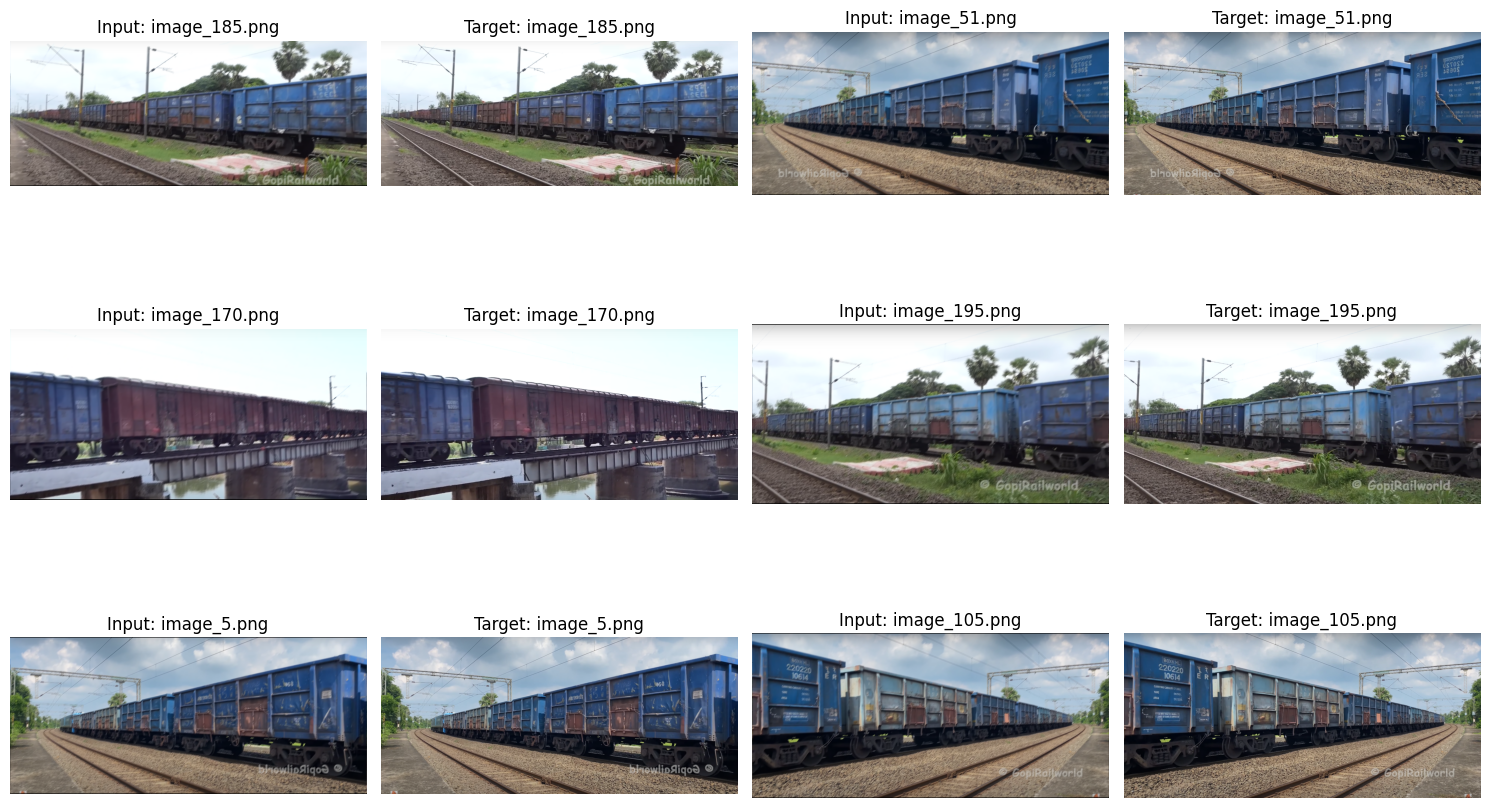

     filename  input_mean_brightness  target_mean_brightness
image_185.png                 138.16                  139.76
 image_51.png                 114.27                  115.43
image_170.png                 140.75                  142.48
image_195.png                 135.09                  136.41
  image_5.png                 115.54                  116.83
image_105.png                 115.56                  116.73


In [5]:
sample_rows = metadata.sample(n=min(6, len(metadata)), random_state=42)
brightness_rows = []

plt.figure(figsize=(15, 10))
for plot_number, (_, row) in enumerate(sample_rows.iterrows(), start=1):
    input_image = Image.open(row['input_path']).convert('RGB')
    target_image = Image.open(row['target_path']).convert('RGB')
    input_array = np.asarray(input_image).astype(np.float32)
    target_array = np.asarray(target_image).astype(np.float32)
    brightness_rows.append({
        'filename': row['filename'],
        'input_mean_brightness': round(float(input_array.mean()), 2),
        'target_mean_brightness': round(float(target_array.mean()), 2)
    })

    plt.subplot(3, 4, plot_number * 2 - 1)
    plt.imshow(input_image)
    plt.title('Input: ' + row['filename'])
    plt.axis('off')
    plt.subplot(3, 4, plot_number * 2)
    plt.imshow(target_image)
    plt.title('Target: ' + row['filename'])
    plt.axis('off')

plt.tight_layout()
plt.show()

brightness = pd.DataFrame(brightness_rows)
print(brightness.to_string(index=False))

## 3. Prepare YOLO annotation files

The current images do not contain bounding-box labels. This cell creates the folders and templates needed for manual annotation. Do not train YOLO until the box coordinates are filled in.

In [6]:
YOLO_ROOT = PROJECT_FOLDER / 'yolo_wagon'
for folder in [
    YOLO_ROOT / 'images' / 'train',
    YOLO_ROOT / 'images' / 'validation',
    YOLO_ROOT / 'images' / 'test',
    YOLO_ROOT / 'labels' / 'train',
    YOLO_ROOT / 'labels' / 'validation',
    YOLO_ROOT / 'labels' / 'test'
]:
    folder.mkdir(parents=True, exist_ok=True)

classes_path = YOLO_ROOT / 'classes.txt'
classes_path.write_text('wagon\n', encoding='utf-8')

annotation_template = metadata[['filename', 'input_width', 'input_height', 'split']].copy()
annotation_template['class_name'] = ''
annotation_template['x_min'] = ''
annotation_template['y_min'] = ''
annotation_template['x_max'] = ''
annotation_template['y_max'] = ''
annotation_template['annotation_status'] = 'not_annotated'
annotation_template_path = PROJECT_FOLDER / 'wagon_annotations_template.csv'
annotation_template.to_csv(annotation_template_path, index=False)

print('YOLO folders created at:', YOLO_ROOT)
print('Class file:', classes_path)
print('Annotation template:', annotation_template_path)
print('Images still need to be labeled before YOLO training.')

YOLO folders created at: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon
Class file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\classes.txt
Annotation template: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\wagon_annotations_template.csv
Images still need to be labeled before YOLO training.


### 3.1 Create a coordinate preview

Use the pixel axes in this preview when filling the annotation template. The first YOLO model will label complete wagons; number-region labels will be prepared separately later.

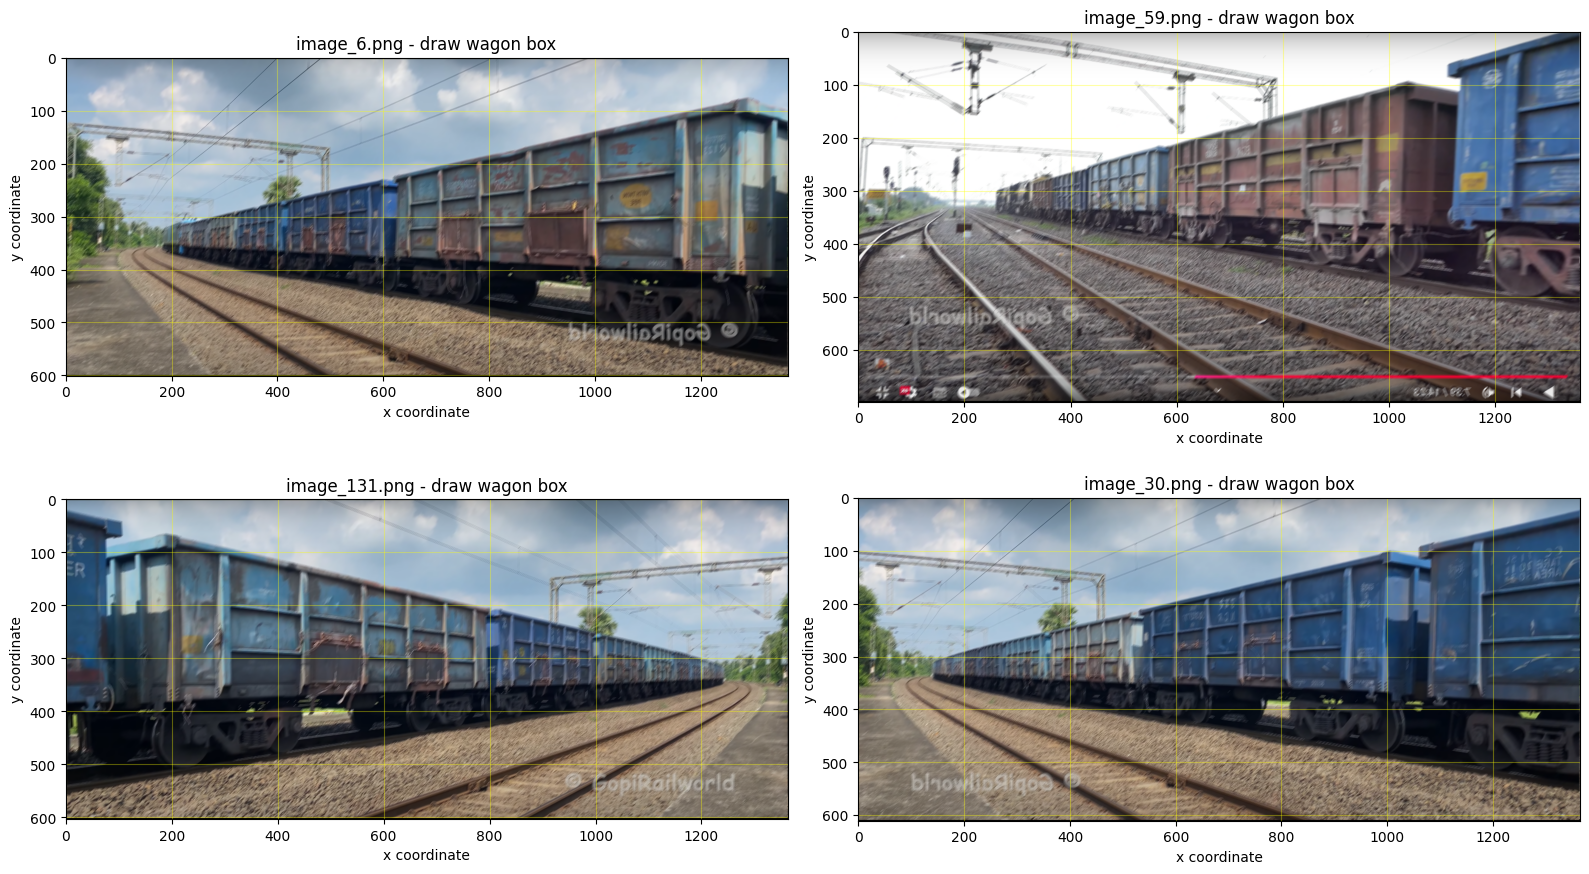

Preview saved to: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_annotation_preview.png


In [7]:
preview_rows = metadata.sample(n=min(4, len(metadata)), random_state=7)
plt.figure(figsize=(16, 9))

for plot_number, (_, row) in enumerate(preview_rows.iterrows(), start=1):
    image = Image.open(row['input_path']).convert('RGB')
    plt.subplot(2, 2, plot_number)
    plt.imshow(image)
    plt.title(row['filename'] + ' - draw wagon box')
    plt.xlabel('x coordinate')
    plt.ylabel('y coordinate')
    plt.grid(color='yellow', alpha=0.35)

plt.tight_layout()
preview_path = PROJECT_FOLDER / 'yolo_annotation_preview.png'
plt.savefig(preview_path, dpi=150)
plt.show()
print('Preview saved to:', preview_path)

## 4. Copy images and create YOLO wagon labels

This stage copies images into their split folders and provides a small function for saving manually measured wagon boxes in YOLO format. The coordinates must come from the preview or an annotation tool.

In [8]:
import shutil

for _, row in metadata.iterrows():
    split_name = row['split']
    destination = YOLO_ROOT / 'images' / split_name / row['filename']
    shutil.copy2(row['input_path'], destination)

print('Copied images:', len(metadata))
print('Use class 0 for every wagon box.')

Copied images: 252
Use class 0 for every wagon box.


In [9]:
def pixel_box_to_yolo(x_min, y_min, x_max, y_max, image_width, image_height):
    x_min = max(0, min(float(x_min), image_width))
    y_min = max(0, min(float(y_min), image_height))
    x_max = max(0, min(float(x_max), image_width))
    y_max = max(0, min(float(y_max), image_height))

    if x_max <= x_min or y_max <= y_min:
        raise ValueError('The box must have positive width and height.')

    box_width = x_max - x_min
    box_height = y_max - y_min
    center_x = x_min + box_width / 2
    center_y = y_min + box_height / 2

    return (
        center_x / image_width,
        center_y / image_height,
        box_width / image_width,
        box_height / image_height
    )


def save_wagon_labels(filename, boxes):
    image_path = INPUT_FOLDER / filename
    if not image_path.exists():
        raise FileNotFoundError('Image not found: ' + str(image_path))

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    yolo_boxes = []
    for box in boxes:
        values = pixel_box_to_yolo(*box, image_width, image_height)
        yolo_boxes.append('0 ' + ' '.join(f'{value:.6f}' for value in values))

    split_name = metadata.loc[metadata['filename'] == filename, 'split'].iloc[0]
    label_path = YOLO_ROOT / 'labels' / split_name / (Path(filename).stem + '.txt')
    label_path.write_text('\n'.join(yolo_boxes) + '\n', encoding='utf-8')
    print('Saved', len(boxes), 'wagon box(es) to:', label_path)

print('Function ready.')
print("Example: save_wagon_labels('image_1.png', [(100, 120, 1300, 460)])")

Function ready.
Example: save_wagon_labels('image_1.png', [(100, 120, 1300, 460)])


### How to annotate one image

1. Open `yolo_annotation_preview.png` or the original image.
2. Record each wagon box as `(x_min, y_min, x_max, y_max)` in pixels.
3. Run, for example:

```python
save_wagon_labels('image_1.png', [(100, 120, 1300, 460)])
```

For multiple wagons, add multiple boxes inside the list. Repeat this for the images selected for YOLO training.

In [10]:
def check_yolo_labels():
    label_count = 0
    invalid_lines = []

    for label_path in YOLO_ROOT.glob('labels/*/*.txt'):
        label_count += 1
        for line_number, line in enumerate(label_path.read_text(encoding='utf-8').splitlines(), start=1):
            parts = line.split()
            if len(parts) != 5:
                invalid_lines.append(str(label_path) + ':' + str(line_number))
                continue
            values = [float(value) for value in parts[1:]]
            if parts[0] != '0' or any(value < 0 or value > 1 for value in values):
                invalid_lines.append(str(label_path) + ':' + str(line_number))

    print('Label files found:', label_count)
    print('Invalid label lines:', len(invalid_lines))
    if invalid_lines:
        print('First invalid line:', invalid_lines[0])

print('Run check_yolo_labels() after adding annotations.')

Run check_yolo_labels() after adding annotations.


## 5. Train the YOLO wagon detector

YOLO training requires label files in `yolo_wagon/labels`. The following cells prepare Ultralytics YOLO and refuse to start if labels are missing.

In [11]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
yolo_data_yaml = YOLO_ROOT / 'data.yaml'
yolo_root_text = YOLO_ROOT.as_posix()
yolo_data_yaml.write_text(
    'path: ' + yolo_root_text + '\n'
    'train: images/train\n'
    'val: images/validation\n'
    'test: images/test\n'
    'names:\n'
    '  0: wagon\n',
    encoding='utf-8'
)

label_files = list((YOLO_ROOT / 'labels').glob('*/*.txt'))
print('YOLO data file:', yolo_data_yaml)
print('Label files available:', len(label_files))

YOLO data file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\data.yaml
Label files available: 252


In [13]:
def train_wagon_detector():
    label_files = list((YOLO_ROOT / 'labels').glob('*/*.txt'))
    if len(label_files) == 0:
        print('YOLO training skipped: annotate wagons first, then run this cell again.')
        return None

    from ultralytics import YOLO

    training_device = 0 if torch.cuda.is_available() else 'cpu'
    yolo_model = YOLO('yolov8n.pt')
    yolo_model.train(
        data=str(yolo_data_yaml),
        epochs=50,
        imgsz=640,
        batch=2,
        workers=2,
        cache=False,
        amp=True,
        project=str(PROJECT_FOLDER / 'yolo_runs'),
        name='wagon_detector',
        device=training_device
    )
    print('Training completed.')
    return yolo_model


yolo_model = train_wagon_detector()

New https://pypi.org/project/ultralytics/8.4.165 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.155  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

In [14]:
if yolo_model is not None:
    test_image_count = len(list((YOLO_ROOT / 'images' / 'test').glob('*.*')))
    evaluation_split = 'test' if test_image_count > 0 else 'val'
    validation_results = yolo_model.val(
        data=str(yolo_data_yaml),
        split=evaluation_split,
        imgsz=640,
        batch=1,
        workers=2,
        device=0 if torch.cuda.is_available() else 'cpu'
    )
    print('Evaluation split:', evaluation_split)
    print('Evaluation completed.')
else:
    print('Run the training cell after adding labels.')

Ultralytics 8.4.155  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 131.139.4 MB/s, size: 1029.9 KB)
val: Scanning D:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\labels\test... 0 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 202.4it/s 0.1s.1s
WARNING val: No labels found in D:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\labels\test.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
val: New cache created: D:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\labels\test.cache
WARNING Labels are missing or empty in D:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_wagon\labels\test.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P        

c:\Users\Aarya Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:700: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
c:\Users\Aarya Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Aarya Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:747: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:\Users\Aarya Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\Aarya Shah\AppData\Local\Programs\Python\Python312\Lib\site-packages\ultralytics\utils\metrics.py:747: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
c:

                   all         26          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 1.1ms preprocess, 23.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to D:\B.Tech\7th Sem\Minor Project\runs\detect\val-3
Evaluation split: test
Evaluation completed.


## 6. Prepare number-region annotations

The second YOLO model detects only the small printed number area inside a wagon. These labels are separate from the complete-wagon labels used in Stage 4.

In [15]:
NUMBER_YOLO_ROOT = PROJECT_FOLDER / 'yolo_number'
for folder in [
    NUMBER_YOLO_ROOT / 'images' / 'train',
    NUMBER_YOLO_ROOT / 'images' / 'validation',
    NUMBER_YOLO_ROOT / 'images' / 'test',
    NUMBER_YOLO_ROOT / 'labels' / 'train',
    NUMBER_YOLO_ROOT / 'labels' / 'validation',
    NUMBER_YOLO_ROOT / 'labels' / 'test'
]:
    folder.mkdir(parents=True, exist_ok=True)

for _, row in metadata.iterrows():
    destination = NUMBER_YOLO_ROOT / 'images' / row['split'] / row['filename']
    shutil.copy2(row['input_path'], destination)

number_classes_path = NUMBER_YOLO_ROOT / 'classes.txt'
number_classes_path.write_text('number_region\n', encoding='utf-8')

number_data_yaml = NUMBER_YOLO_ROOT / 'data.yaml'
number_data_yaml.write_text(
    'path: ' + NUMBER_YOLO_ROOT.as_posix() + '\n'
    'train: images/train\n'
    'val: images/validation\n'
    'test: images/test\n'
    'names:\n'
    '  0: number_region\n',
    encoding='utf-8'
)

print('Number-region dataset created at:', NUMBER_YOLO_ROOT)
print('Images copied:', len(metadata))
print('Number class file:', number_classes_path)
print('Labels still need manual annotation.')

Number-region dataset created at: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_number
Images copied: 252
Number class file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_number\classes.txt
Labels still need manual annotation.


In [16]:
def save_number_labels(filename, boxes):
    image_path = INPUT_FOLDER / filename
    if not image_path.exists():
        raise FileNotFoundError('Image not found: ' + str(image_path))

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    yolo_boxes = []
    for box in boxes:
        values = pixel_box_to_yolo(*box, image_width, image_height)
        yolo_boxes.append('0 ' + ' '.join(f'{value:.6f}' for value in values))

    split_name = metadata.loc[metadata['filename'] == filename, 'split'].iloc[0]
    label_path = NUMBER_YOLO_ROOT / 'labels' / split_name / (Path(filename).stem + '.txt')
    label_path.write_text('\n'.join(yolo_boxes) + '\n', encoding='utf-8')
    print('Saved', len(boxes), 'number-region box(es) to:', label_path)


def count_number_labels():
    label_files = list((NUMBER_YOLO_ROOT / 'labels').glob('*/*.txt'))
    print('Number-region label files:', len(label_files))
    return len(label_files)

print("Example: save_number_labels('image_1.png', [(700, 180, 850, 250)])")
print('Use one box around each visible printed wagon number.')

Example: save_number_labels('image_1.png', [(700, 180, 850, 250)])
Use one box around each visible printed wagon number.


## 7. Train the number-region detector

This is a separate YOLO model from the wagon detector. It learns to find the smaller printed-number area inside a wagon.

The settings use low memory because the project targets an RTX 3050 with 4 GB VRAM.

In [17]:
def train_number_detector():
    label_files = list((NUMBER_YOLO_ROOT / 'labels').glob('*/*.txt'))
    if len(label_files) == 0:
        print('Number-detector training skipped: create number-region labels first.')
        return None

    from ultralytics import YOLO

    training_device = 0 if torch.cuda.is_available() else 'cpu'
    number_model = YOLO('yolov8n.pt')
    number_model.train(
        data=str(number_data_yaml),
        epochs=25,
        imgsz=640,
        batch=2,
        workers=2,
        cache=False,
        amp=True,
        project=str(PROJECT_FOLDER / 'yolo_runs'),
        name='number_detector',
        device=training_device
    )
    print('Number-detector training completed.')
    return number_model


number_model = train_number_detector()

New https://pypi.org/project/ultralytics/8.4.165 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.155  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_number\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask

## 7.1 Evaluate the number-region detector

Use validation data because the current number dataset does not contain a separate test split.

In [18]:
if number_model is not None:
    number_validation_results = number_model.val(
        data=str(number_data_yaml),
        split='val',
        imgsz=640,
        batch=1,
        workers=2,
        device=0 if torch.cuda.is_available() else 'cpu'
    )
    print('Number-detector validation completed.')
else:
    print('Run the number-detector training cell after adding labels.')

Ultralytics 8.4.155  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1794.3263.2 MB/s, size: 1380.7 KB)
val: Scanning D:\B.Tech\7th Sem\Minor Project\Wagon Dataset\yolo_number\labels\validation.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 7.2it/s 3.5s<0.1s
                   all         25         25      0.945       0.92      0.977      0.671
Speed: 1.1ms preprocess, 14.0ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to D:\B.Tech\7th Sem\Minor Project\runs\detect\val-4
Number-detector validation completed.


## 8. Crop number regions for restoration and OCR

This stage runs the trained number detector one image at a time and saves only the detected number-region crops. Cropping before OCR and restoration reduces memory use and keeps the later stages suitable for a 4 GB GPU.

In [20]:
from PIL import Image

NUMBER_CROPS_FOLDER = PROJECT_FOLDER / 'number_crops'
NUMBER_CROPS_FOLDER.mkdir(parents=True, exist_ok=True)

NUMBER_MODEL_CANDIDATES = [
    PROJECT_FOLDER / 'yolo_runs' / 'number_detector' / 'weights' / 'best.pt',
    PROJECT_FOLDER.parent / 'runs' / 'detect' / 'Wagon Dataset' / 'yolo_runs' / 'number_detector' / 'weights' / 'best.pt',
    PROJECT_FOLDER.parent / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt'
]


def find_number_model_path():
    for model_path in NUMBER_MODEL_CANDIDATES:
        if model_path.exists():
            return model_path
    raise FileNotFoundError('Number-detector weights were not found. Run Stage 7 first.')


def crop_number_regions():
    from ultralytics import YOLO

    model_path = find_number_model_path()
    number_model = YOLO(str(model_path))
    inference_device = 0 if torch.cuda.is_available() else 'cpu'
    crop_count = 0
    image_count = 0

    image_paths = sorted(INPUT_FOLDER.glob('*.png'))
    for image_path in image_paths:
        with Image.open(image_path) as image:
            image_width, image_height = image.size
            image_copy = image.convert('RGB')

        results = number_model.predict(
            source=str(image_path),
            imgsz=640,
            conf=0.25,
            batch=1,
            device=inference_device,
            verbose=False,
            save=False
        )

        image_regions = 0
        for region_index, region in enumerate(results[0].boxes.xyxy.cpu().tolist(), start=1):
            x_min, y_min, x_max, y_max = [int(value) for value in region]
            x_min = max(0, min(x_min, image_width - 1))
            y_min = max(0, min(y_min, image_height - 1))
            x_max = max(x_min + 1, min(x_max, image_width))
            y_max = max(y_min + 1, min(y_max, image_height))
            crop = image_copy.crop((x_min, y_min, x_max, y_max))
            crop_path = NUMBER_CROPS_FOLDER / f'{image_path.stem}_region_{region_index:02d}.png'
            crop.save(crop_path)
            crop_count += 1
            image_regions += 1

        image_copy.close()
        image_count += 1

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print('Images processed:', image_count)
    print('Number-region crops saved:', crop_count)
    print('Crop folder:', NUMBER_CROPS_FOLDER)
    return crop_count


number_crop_count = crop_number_regions()

Images processed: 252
Number-region crops saved: 342
Crop folder: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\number_crops


## 9. Prepare OCR-ready crop variants

This baseline preprocessing works on the small number crops only. It uses CPU-friendly OpenCV operations and does not load a large image batch into the 4 GB GPU.

In [21]:
import cv2

OCR_READY_FOLDER = PROJECT_FOLDER / 'ocr_ready'
OCR_READY_FOLDER.mkdir(parents=True, exist_ok=True)


def prepare_ocr_crops():
    crop_paths = sorted(NUMBER_CROPS_FOLDER.glob('*.png'))
    if not crop_paths:
        raise FileNotFoundError('No number crops found. Run Stage 8 first.')

    processed_count = 0
    for crop_path in crop_paths:
        image = cv2.imread(str(crop_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue

        enlarged = cv2.resize(image, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
        smoothed = cv2.GaussianBlur(enlarged, (3, 3), 0)
        _, thresholded = cv2.threshold(
            smoothed,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        output_path = OCR_READY_FOLDER / crop_path.name
        cv2.imwrite(str(output_path), thresholded)
        processed_count += 1

    print('Input number crops:', len(crop_paths))
    print('OCR-ready crops saved:', processed_count)
    print('OCR-ready folder:', OCR_READY_FOLDER)
    return processed_count


ocr_ready_count = prepare_ocr_crops()

Input number crops: 342
OCR-ready crops saved: 342
OCR-ready folder: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\ocr_ready


## 10. Run baseline OCR

This stage reads the OCR-ready crops with Tesseract. It records raw predictions only; accuracy will be measured after real number labels are added.

In [23]:
import os
import shutil
import pytesseract

OCR_RESULTS_PATH = PROJECT_FOLDER / 'ocr_baseline.csv'
TESSERACT_PATH_CANDIDATES = [
    r'C:\Program Files\Tesseract-OCR\tesseract.exe',
    r'C:\Program Files (x86)\Tesseract-OCR\tesseract.exe'
]


def configure_tesseract():
    for tesseract_path in TESSERACT_PATH_CANDIDATES:
        if os.path.exists(tesseract_path):
            pytesseract.pytesseract.tesseract_cmd = tesseract_path
            return tesseract_path

    path_from_system = shutil.which('tesseract')
    if path_from_system:
        pytesseract.pytesseract.tesseract_cmd = path_from_system
        return path_from_system

    raise FileNotFoundError(
        'Tesseract OCR is not installed. Install the Windows Tesseract application first.'
    )


def clean_ocr_text(text):
    return ''.join(character for character in text if character.isdigit())


def run_baseline_ocr():
    crop_paths = sorted(OCR_READY_FOLDER.glob('*.png'))
    if not crop_paths:
        raise FileNotFoundError('No OCR-ready crops found. Run Stage 9 first.')

    try:
        tesseract_path = configure_tesseract()
        ocr_available = True
        availability_message = 'Tesseract path: ' + str(tesseract_path)
    except FileNotFoundError as error:
        ocr_available = False
        availability_message = str(error)

    rows = []
    for crop_path in crop_paths:
        if not ocr_available:
            rows.append({
                'crop_file': crop_path.name,
                'predicted_number': '',
                'status': 'tesseract_not_available'
            })
            continue

        image = cv2.imread(str(crop_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            rows.append({
                'crop_file': crop_path.name,
                'predicted_number': '',
                'status': 'image_read_failed'
            })
            continue

        settings = '--psm 7 -c tessedit_char_whitelist=0123456789'
        raw_text = pytesseract.image_to_string(image, config=settings)
        rows.append({
            'crop_file': crop_path.name,
            'predicted_number': clean_ocr_text(raw_text),
            'status': 'ok'
        })

    results = pd.DataFrame(rows)
    results.to_csv(OCR_RESULTS_PATH, index=False)
    print(availability_message)
    print('OCR crops processed:', len(results))
    print('OCR result file:', OCR_RESULTS_PATH)
    print(results['status'].value_counts().to_string())
    return results


ocr_results = run_baseline_ocr()

Tesseract path: C:\Program Files\Tesseract-OCR\tesseract.exe
OCR crops processed: 342
OCR result file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\ocr_baseline.csv
status
ok    342


## 11. Train a lightweight deblurring model

This is the first restoration model for the paired blurred/sharp images. It is intentionally small and uses 256x256 images, batch size 2, and one data-loading worker for the 4 GB GPU.

In [24]:
class PairedDeblurDataset(Dataset):
    def __init__(self, metadata_frame, split_name):
        self.rows = metadata_frame[metadata_frame['split'] == split_name].reset_index(drop=True)
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        blurred = Image.open(row['input_path']).convert('RGB')
        sharp = Image.open(row['target_path']).convert('RGB')
        return self.transform(blurred), self.transform(sharp), row['filename']


class SmallDeblurCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, image):
        return self.layers(image)


if 'number_model' in globals():
    del number_model
if 'yolo_model' in globals():
    del yolo_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


def train_deblur_model():
    train_dataset = PairedDeblurDataset(metadata, 'train')
    validation_dataset = PairedDeblurDataset(metadata, 'validation')
    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    model = SmallDeblurCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_function = nn.L1Loss()
    history = []

    for epoch in range(5):
        model.train()
        total_loss = 0.0
        for blurred, sharp, _ in train_loader:
            blurred = blurred.to(DEVICE)
            sharp = sharp.to(DEVICE)
            optimizer.zero_grad()
            restored = model(blurred)
            loss = loss_function(restored, sharp)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        average_loss = total_loss / max(1, len(train_loader))
        history.append({'epoch': epoch + 1, 'train_l1_loss': average_loss})
        print('Epoch', epoch + 1, 'of 5 - training L1 loss:', round(average_loss, 6))

    model_path = MODEL_FOLDER / 'small_deblur_cnn.pt'
    torch.save(model.state_dict(), model_path)
    print('Deblur model saved to:', model_path)
    print('Validation images available:', len(validation_dataset))
    return model, validation_loader, history


deblur_model, deblur_validation_loader, deblur_history = train_deblur_model()

Epoch 1 of 5 - training L1 loss: 0.107748
Epoch 2 of 5 - training L1 loss: 0.046502
Epoch 3 of 5 - training L1 loss: 0.04141
Epoch 4 of 5 - training L1 loss: 0.040329
Epoch 5 of 5 - training L1 loss: 0.039804
Deblur model saved to: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\models\small_deblur_cnn.pt
Validation images available: 25


## 11.1 Evaluate restoration quality

PSNR and SSIM are measured on the validation images after resizing them to the same 256x256 comparison size.

In [25]:
def evaluate_deblur_model(model, validation_loader):
    model.eval()
    psnr_values = []
    ssim_values = []

    with torch.no_grad():
        for blurred, sharp, _ in validation_loader:
            restored = model(blurred.to(DEVICE)).cpu().numpy()[0].transpose(1, 2, 0)
            target = sharp.numpy()[0].transpose(1, 2, 0)
            restored = np.clip(restored, 0, 1)
            psnr_values.append(peak_signal_noise_ratio(target, restored, data_range=1.0))
            ssim_values.append(
                structural_similarity(
                    target,
                    restored,
                    channel_axis=2,
                    data_range=1.0
                )
            )

    print('Validation PSNR:', round(float(np.mean(psnr_values)), 4))
    print('Validation SSIM:', round(float(np.mean(ssim_values)), 4))
    return psnr_values, ssim_values


deblur_psnr_values, deblur_ssim_values = evaluate_deblur_model(
    deblur_model,
    deblur_validation_loader
)

Validation PSNR: 25.907
Validation SSIM: 0.8519


## 12. Apply deblurring to number-region crops

This stage applies the trained baseline CNN to each detected number crop one at a time. The output keeps the original crop size for later comparison and OCR.

In [27]:
DEBLURRED_CROPS_FOLDER = PROJECT_FOLDER / 'deblur_outputs'
DEBLURRED_CROPS_FOLDER.mkdir(parents=True, exist_ok=True)
DEBLUR_MODEL_PATH = MODEL_FOLDER / 'small_deblur_cnn.pt'


def restore_number_crops():
    if not DEBLUR_MODEL_PATH.exists():
        raise FileNotFoundError('Deblur model not found. Run Stage 11 first.')

    crop_paths = sorted(NUMBER_CROPS_FOLDER.glob('*.png'))
    if not crop_paths:
        raise FileNotFoundError('Number crops not found. Run Stage 8 first.')

    model = SmallDeblurCNN().to(DEVICE)
    state_dict = torch.load(DEBLUR_MODEL_PATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    resize_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    to_image = transforms.ToPILImage()
    restored_count = 0

    with torch.no_grad():
        for crop_path in crop_paths:
            with Image.open(crop_path) as crop_image:
                original_size = crop_image.size
                input_tensor = resize_transform(crop_image.convert('RGB')).unsqueeze(0)

            restored_tensor = model(input_tensor.to(DEVICE))[0].cpu().clamp(0, 1)
            restored_image = to_image(restored_tensor).resize(original_size, Image.Resampling.LANCZOS)
            restored_image.save(DEBLURRED_CROPS_FOLDER / crop_path.name)
            restored_count += 1

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print('Number crops processed:', len(crop_paths))
    print('Deblurred crops saved:', restored_count)
    print('Deblurred crop folder:', DEBLURRED_CROPS_FOLDER)
    return restored_count


deblurred_crop_count = restore_number_crops()

Number crops processed: 342
Deblurred crops saved: 342
Deblurred crop folder: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\deblur_outputs


## 13. Compare original, OCR-ready, and deblurred crops

This stage creates a comparison table and a small visual contact sheet. The sharpness numbers describe image changes; they are not final restoration accuracy because matching sharp number-region targets are not available yet.

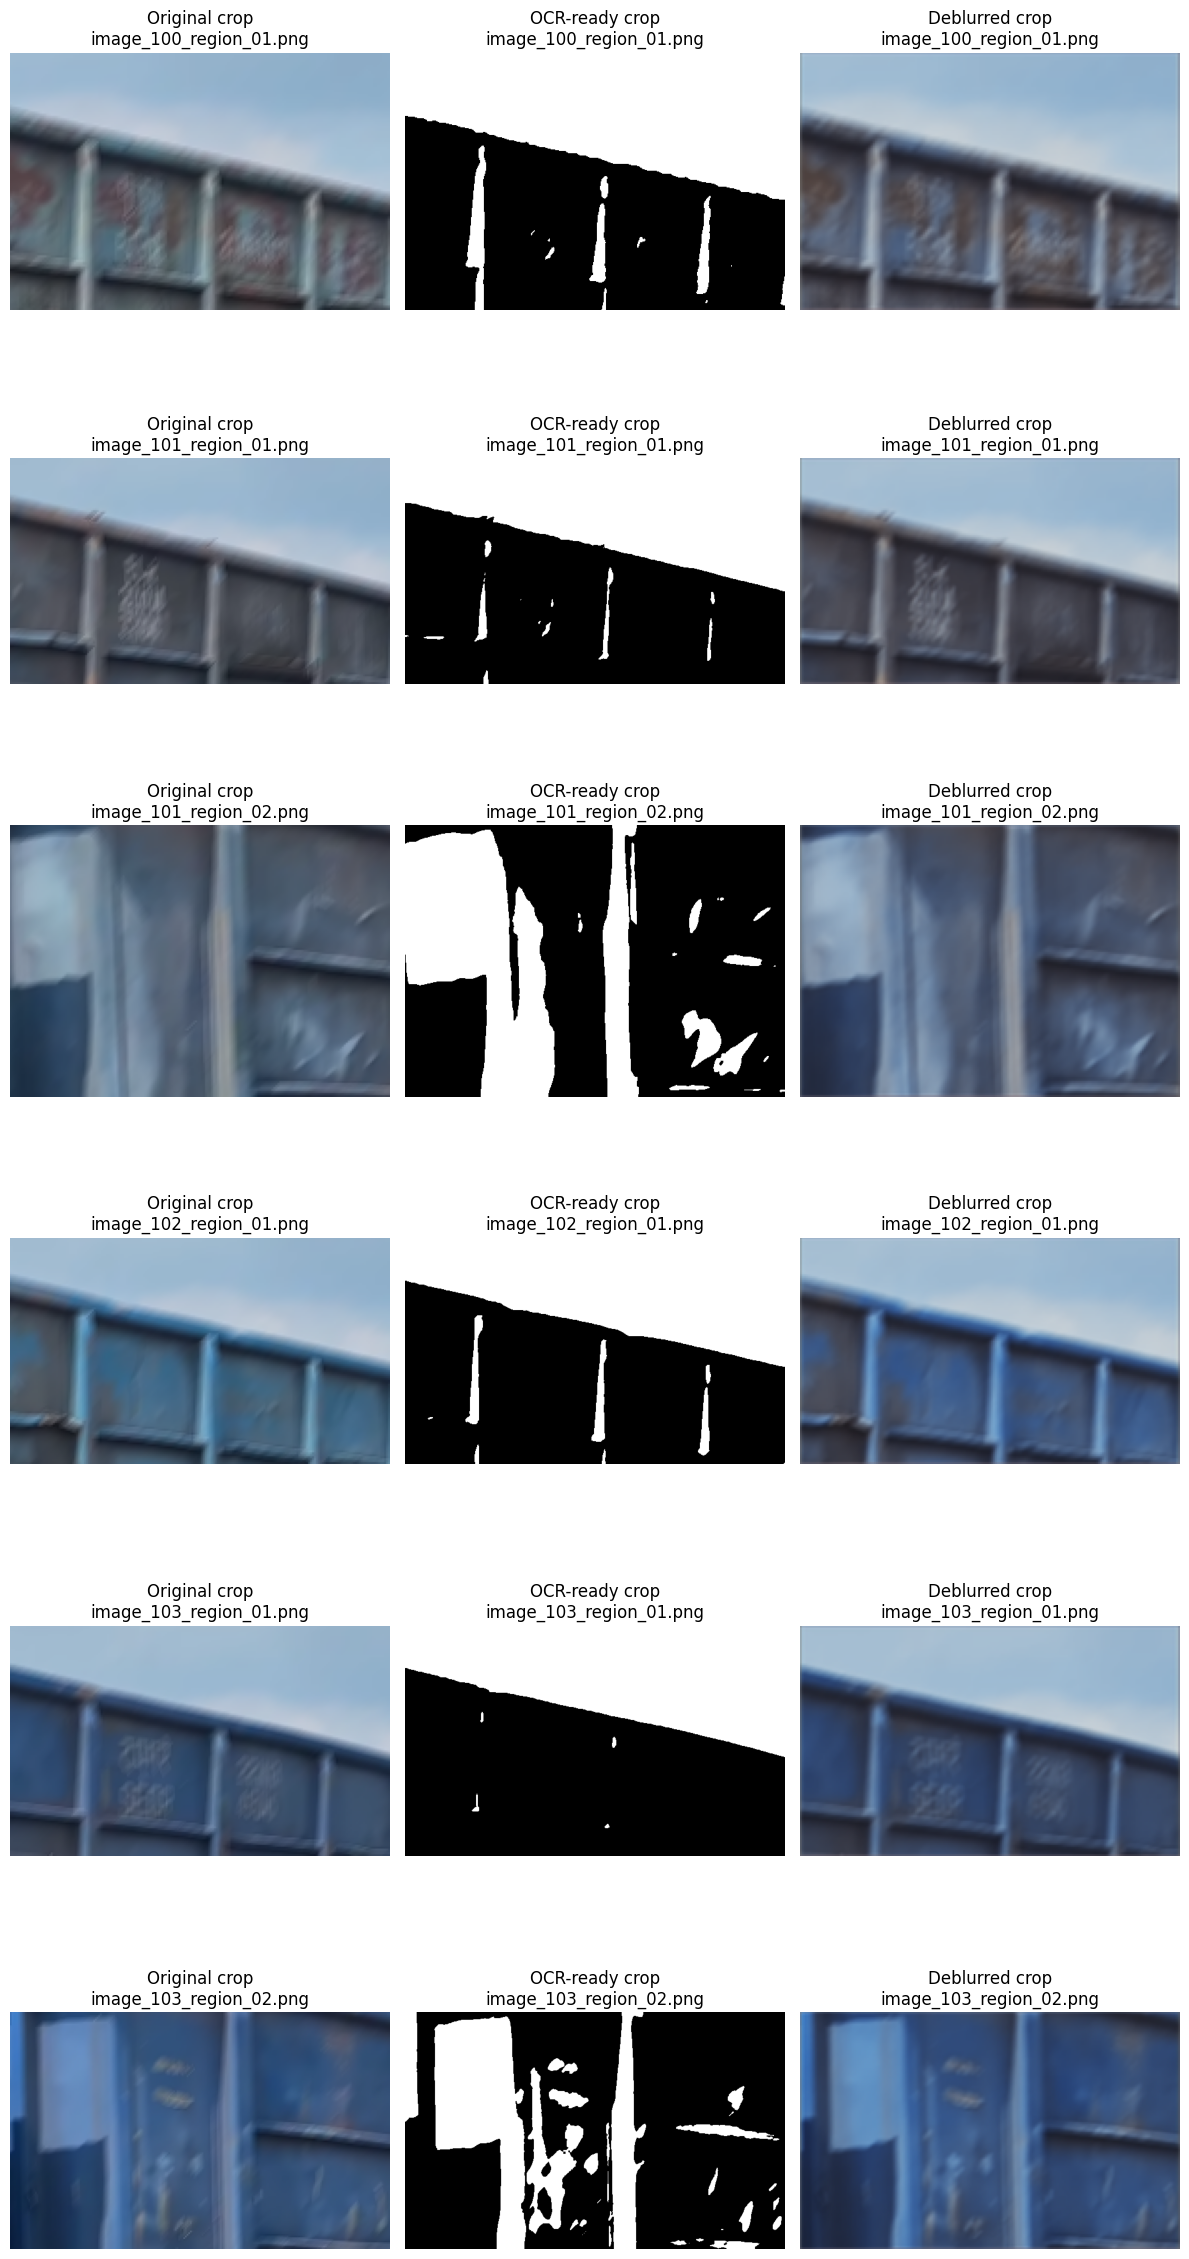

Comparison rows: 342
Mean original sharpness: 57.6086
Mean OCR-ready sharpness: 2490.6267
Mean deblurred sharpness: 57.5158
Comparison CSV: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\deblur_comparison.csv
Preview image: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\deblur_comparison_preview.png


In [28]:
COMPARISON_RESULTS_PATH = PROJECT_FOLDER / 'deblur_comparison.csv'
COMPARISON_PREVIEW_PATH = PROJECT_FOLDER / 'deblur_comparison_preview.png'


def calculate_crop_sharpness(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    return float(cv2.Laplacian(image, cv2.CV_64F).var())


def compare_crop_versions():
    crop_paths = sorted(NUMBER_CROPS_FOLDER.glob('*.png'))
    if not crop_paths:
        raise FileNotFoundError('Number crops not found. Run Stage 8 first.')

    rows = []
    for crop_path in crop_paths:
        ocr_path = OCR_READY_FOLDER / crop_path.name
        deblur_path = DEBLURRED_CROPS_FOLDER / crop_path.name
        original = cv2.imread(str(crop_path), cv2.IMREAD_GRAYSCALE)
        deblurred = cv2.imread(str(deblur_path), cv2.IMREAD_GRAYSCALE)
        if original is None or deblurred is None:
            continue

        deblurred_resized = cv2.resize(
            deblurred,
            (original.shape[1], original.shape[0]),
            interpolation=cv2.INTER_AREA
        )
        mean_absolute_change = float(
            np.mean(np.abs(original.astype(np.float32) - deblurred_resized.astype(np.float32)))
        )
        rows.append({
            'crop_file': crop_path.name,
            'original_sharpness': calculate_crop_sharpness(crop_path),
            'ocr_ready_sharpness': calculate_crop_sharpness(ocr_path),
            'deblurred_sharpness': calculate_crop_sharpness(deblur_path),
            'mean_absolute_change': mean_absolute_change
        })

    comparison = pd.DataFrame(rows)
    comparison.to_csv(COMPARISON_RESULTS_PATH, index=False)

    preview_paths = crop_paths[:6]
    plt.figure(figsize=(12, 4 * len(preview_paths)))
    for row_number, crop_path in enumerate(preview_paths, start=1):
        image_versions = [
            ('Original crop', crop_path),
            ('OCR-ready crop', OCR_READY_FOLDER / crop_path.name),
            ('Deblurred crop', DEBLURRED_CROPS_FOLDER / crop_path.name)
        ]
        for column_number, (title, image_path) in enumerate(image_versions, start=1):
            image = Image.open(image_path).convert('RGB')
            position = (row_number - 1) * 3 + column_number
            plt.subplot(len(preview_paths), 3, position)
            plt.imshow(image)
            plt.title(title + '\n' + crop_path.name)
            plt.axis('off')

    plt.tight_layout()
    plt.savefig(COMPARISON_PREVIEW_PATH, dpi=120)
    plt.show()

    print('Comparison rows:', len(comparison))
    print('Mean original sharpness:', round(comparison['original_sharpness'].mean(), 4))
    print('Mean OCR-ready sharpness:', round(comparison['ocr_ready_sharpness'].mean(), 4))
    print('Mean deblurred sharpness:', round(comparison['deblurred_sharpness'].mean(), 4))
    print('Comparison CSV:', COMPARISON_RESULTS_PATH)
    print('Preview image:', COMPARISON_PREVIEW_PATH)
    return comparison


crop_comparison = compare_crop_versions()

## 14. Compare OCR inputs

This stage runs OCR on the original, OCR-ready, and deblurred versions of each crop. It records predictions only; accuracy needs real number labels.

In [29]:
OCR_COMPARISON_PATH = PROJECT_FOLDER / 'ocr_input_comparison.csv'


def run_ocr_comparison():
    crop_paths = sorted(NUMBER_CROPS_FOLDER.glob('*.png'))
    if not crop_paths:
        raise FileNotFoundError('Number crops not found. Run Stage 8 first.')

    try:
        configure_tesseract()
        ocr_available = True
    except FileNotFoundError:
        ocr_available = False

    rows = []
    for crop_path in crop_paths:
        row = {'crop_file': crop_path.name}
        image_paths = {
            'original': crop_path,
            'ocr_ready': OCR_READY_FOLDER / crop_path.name,
            'deblurred': DEBLURRED_CROPS_FOLDER / crop_path.name
        }

        for version_name, image_path in image_paths.items():
            status_key = version_name + '_status'
            text_key = version_name + '_prediction'
            if not ocr_available:
                row[text_key] = ''
                row[status_key] = 'tesseract_not_available'
                continue

            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                row[text_key] = ''
                row[status_key] = 'image_read_failed'
                continue

            settings = '--psm 7 -c tessedit_char_whitelist=0123456789'
            raw_text = pytesseract.image_to_string(image, config=settings)
            row[text_key] = clean_ocr_text(raw_text)
            row[status_key] = 'ok'

        rows.append(row)

    comparison = pd.DataFrame(rows)
    comparison.to_csv(OCR_COMPARISON_PATH, index=False)
    print('OCR comparison rows:', len(comparison))
    print('Tesseract available:', ocr_available)
    print('OCR comparison file:', OCR_COMPARISON_PATH)
    return comparison


ocr_input_comparison = run_ocr_comparison()

OCR comparison rows: 342
Tesseract available: True
OCR comparison file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\ocr_input_comparison.csv


## 15. Prepare ground-truth OCR evaluation

Real wagon numbers are required before reporting OCR accuracy. This stage creates a template and provides exact-match, CER, and UIC-validity measurements when the template is filled.

In [9]:
ALIGNED_LABELS_PATH = PROJECT_FOLDER / 'number_labels_aligned.csv'
GROUND_TRUTH_PATH = ALIGNED_LABELS_PATH if ALIGNED_LABELS_PATH.exists() else PROJECT_FOLDER / 'number_labels.csv'
GROUND_TRUTH_TEMPLATE_PATH = PROJECT_FOLDER / 'number_labels_template.csv'
NUMBER_CROPS_FOLDER = PROJECT_FOLDER / 'number_crops'
OCR_COMPARISON_PATH = PROJECT_FOLDER / 'ocr_input_comparison.csv'


def normalize_digits(value):
    return ''.join(character for character in str(value) if character.isdigit())


def edit_distance(first_text, second_text):
    previous_row = list(range(len(second_text) + 1))
    for first_index, first_character in enumerate(first_text, start=1):
        current_row = [first_index]
        for second_index, second_character in enumerate(second_text, start=1):
            insert_cost = current_row[second_index - 1] + 1
            delete_cost = previous_row[second_index] + 1
            replace_cost = previous_row[second_index - 1] + (first_character != second_character)
            current_row.append(min(insert_cost, delete_cost, replace_cost))
        previous_row = current_row
    return previous_row[-1]


def is_valid_uic_number(number_text):
    digits = normalize_digits(number_text)
    if len(digits) != 12:
        return False

    total = 0
    for position in range(11):
        digit = int(digits[10 - position])
        weight = 2 if position % 2 == 0 else 1
        total += sum(int(value) for value in str(digit * weight))

    check_digit = (10 - (total % 10)) % 10
    return check_digit == int(digits[11])


def prepare_ground_truth_template():
    crop_paths = sorted(NUMBER_CROPS_FOLDER.glob('*.png'))
    template = pd.DataFrame({
        'crop_file': [path.name for path in crop_paths],
        'ground_truth_number': [''] * len(crop_paths)
    })
    if not GROUND_TRUTH_PATH.exists():
        template.to_csv(GROUND_TRUTH_TEMPLATE_PATH, index=False)
        print('Ground-truth template created at:', GROUND_TRUTH_TEMPLATE_PATH)
        print('Fill ground_truth_number with the real printed number for each crop.')
    else:
        print('Ground-truth file found:', GROUND_TRUTH_PATH)
    return template


def evaluate_ocr_with_ground_truth():
    if not GROUND_TRUTH_PATH.exists():
        print('OCR accuracy not measured. Create verified labels first.')
        return None

    ground_truth = pd.read_csv(GROUND_TRUTH_PATH, dtype=str).fillna('')
    predictions = pd.read_csv(OCR_COMPARISON_PATH, dtype=str).fillna('')
    merged = predictions.merge(ground_truth, on='crop_file', how='inner')
    merged['ground_truth_number'] = merged['ground_truth_number'].map(normalize_digits)

    summary_rows = []
    for version_name in ['original', 'ocr_ready', 'deblurred']:
        prediction_column = version_name + '_prediction'
        predictions_clean = merged[prediction_column].map(normalize_digits)
        exact_matches = predictions_clean == merged['ground_truth_number']
        total_distance = sum(
            edit_distance(prediction, truth)
            for prediction, truth in zip(predictions_clean, merged['ground_truth_number'])
        )
        truth_length = sum(len(truth) for truth in merged['ground_truth_number'])
        summary_rows.append({
            'version': version_name,
            'samples': len(merged),
            'exact_match_accuracy': float(exact_matches.mean()),
            'character_error_rate': total_distance / max(1, truth_length),
            'valid_uic_predictions': int(predictions_clean.map(is_valid_uic_number).sum())
        })

    summary = pd.DataFrame(summary_rows)
    print('Evaluation labels:', GROUND_TRUTH_PATH)
    print(summary.to_string(index=False))
    return summary


ground_truth_template = prepare_ground_truth_template()
ocr_accuracy_summary = evaluate_ocr_with_ground_truth()

Ground-truth file found: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\number_labels_aligned.csv
Evaluation labels: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\number_labels_aligned.csv
  version  samples  exact_match_accuracy  character_error_rate  valid_uic_predictions
 original      161                   0.0              0.994687                      0
ocr_ready      161                   0.0              0.995277                      0
deblurred      161                   0.0              0.993506                      0


## 16. Review OCR candidates before entering ground truth

OCR output is only a candidate. This review file keeps the three candidates beside a blank verified number column so a person can check each crop image and enter the real printed number.

In [31]:
GROUND_TRUTH_REVIEW_PATH = PROJECT_FOLDER / 'number_labels_review.csv'


def create_ground_truth_review_file():
    if 'ocr_input_comparison' not in globals():
        raise NameError('Run Stage 14 OCR comparison first.')

    review = ocr_input_comparison[[
        'crop_file',
        'original_prediction',
        'ocr_ready_prediction',
        'deblurred_prediction'
    ]].copy()
    review['verified_ground_truth'] = ''
    review['review_status'] = 'needs_human_review'
    review.to_csv(GROUND_TRUTH_REVIEW_PATH, index=False)
    print('Review file created at:', GROUND_TRUTH_REVIEW_PATH)
    print('Rows needing human verification:', len(review))
    print('Use the crop_file name to open the matching image in number_crops.')
    return review


ground_truth_review = create_ground_truth_review_file()

Review file created at: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\number_labels_review.csv
Rows needing human verification: 342
Use the crop_file name to open the matching image in number_crops.


## 17. Create sharp reference crops for labeling

The blurred number crops are not reliable for reading ground truth. This stage uses the same detected coordinates on the paired sharp output images so the real number can be read clearly.

In [32]:
SHARP_NUMBER_CROPS_FOLDER = PROJECT_FOLDER / 'number_target_crops'
SHARP_NUMBER_CROPS_FOLDER.mkdir(parents=True, exist_ok=True)


def create_sharp_reference_crops():
    from ultralytics import YOLO

    model_path = find_number_model_path()
    detector = YOLO(str(model_path))
    inference_device = 0 if torch.cuda.is_available() else 'cpu'
    input_paths = sorted(INPUT_FOLDER.glob('*.png'))
    saved_count = 0

    for input_path in input_paths:
        target_path = TARGET_FOLDER / input_path.name
        if not target_path.exists():
            continue

        with Image.open(input_path) as input_image:
            input_width, input_height = input_image.size
        with Image.open(target_path) as target_image:
            target_copy = target_image.convert('RGB')
            target_width, target_height = target_copy.size

        results = detector.predict(
            source=str(input_path),
            imgsz=640,
            conf=0.25,
            batch=1,
            device=inference_device,
            verbose=False,
            save=False
        )

        scale_x = target_width / input_width
        scale_y = target_height / input_height
        for region_index, region in enumerate(results[0].boxes.xyxy.cpu().tolist(), start=1):
            x_min, y_min, x_max, y_max = region
            x_min = max(0, min(int(x_min * scale_x), target_width - 1))
            y_min = max(0, min(int(y_min * scale_y), target_height - 1))
            x_max = max(x_min + 1, min(int(x_max * scale_x), target_width))
            y_max = max(y_min + 1, min(int(y_max * scale_y), target_height))
            crop_path = SHARP_NUMBER_CROPS_FOLDER / f'{input_path.stem}_region_{region_index:02d}.png'
            target_copy.crop((x_min, y_min, x_max, y_max)).save(crop_path)
            saved_count += 1

        target_copy.close()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print('Sharp reference crops saved:', saved_count)
    print('Sharp reference folder:', SHARP_NUMBER_CROPS_FOLDER)
    print('Use this folder when filling verified_ground_truth.')
    return saved_count


sharp_reference_crop_count = create_sharp_reference_crops()

Sharp reference crops saved: 342
Sharp reference folder: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\number_target_crops
Use this folder when filling verified_ground_truth.


## 18. Align and validate verified labels

This stage uses `crop_file` as the key instead of relying on CSV row order. It prevents manual values from becoming attached to the wrong crop after sorting or editing.

In [2]:
ALIGNED_LABELS_PATH = PROJECT_FOLDER / 'number_labels_aligned.csv'


def align_verified_labels():
    review_path = PROJECT_FOLDER / 'number_labels_review.csv'
    if not review_path.exists():
        raise FileNotFoundError('number_labels_review.csv was not found.')

    review = pd.read_csv(review_path, dtype=str).fillna('')
    review['crop_file'] = review['crop_file'].str.strip()
    review['review_status'] = review['review_status'].str.strip().str.lower()
    verified = review[review['review_status'] == 'verified'].copy()
    verified['ground_truth_number'] = verified['verified_ground_truth'].str.strip()

    if verified['crop_file'].duplicated().any():
        raise ValueError('Duplicate crop_file values found in verified labels.')
    if (verified['ground_truth_number'] == '').any():
        raise ValueError('A verified row has a blank ground-truth number.')

    aligned = verified[['crop_file', 'ground_truth_number']].sort_values('crop_file')
    aligned.to_csv(ALIGNED_LABELS_PATH, index=False)
    print('Verified labels:', len(aligned))
    print('Unreadable rows:', int((review['review_status'] == 'unreadable').sum()))
    print('Invalid-crop rows:', int((review['review_status'] == 'invalid_crop').sum()))
    print('Aligned label file:', ALIGNED_LABELS_PATH)
    return aligned


aligned_labels = align_verified_labels()

Verified labels: 162
Unreadable rows: 117
Invalid-crop rows: 64
Aligned label file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\number_labels_aligned.csv


## 19. Check final evaluation inputs

This CPU-only check prevents spending GPU credits when required generated artifacts are missing after cleanup.

In [3]:
def check_final_evaluation_inputs():
    required_paths = {
        'aligned_labels': PROJECT_FOLDER / 'number_labels_aligned.csv',
        'verified_labels': PROJECT_FOLDER / 'number_labels.csv',
        'number_detector_weights': PROJECT_FOLDER.parent / 'runs' / 'detect' / 'Wagon Dataset' / 'yolo_runs' / 'number_detector' / 'weights' / 'best.pt',
        'ocr_comparison': PROJECT_FOLDER / 'ocr_input_comparison.csv'
    }

    for name, path in required_paths.items():
        print(name + ':', 'available' if path.exists() else 'missing')

    if not required_paths['aligned_labels'].exists():
        raise FileNotFoundError('Run Stage 18 label alignment first.')

    print('No GPU work was performed. Regenerate missing model/output artifacts only when continuing evaluation.')
    return required_paths


final_evaluation_inputs = check_final_evaluation_inputs()

aligned_labels: available
verified_labels: available
number_detector_weights: available
ocr_comparison: missing
No GPU work was performed. Regenerate missing model/output artifacts only when continuing evaluation.


## 20. Regenerate evaluation crops and OCR

This stage reuses existing number-detector weights. It does not retrain YOLO or the deblurring model. Detection uses one image at a time; preprocessing and OCR run on CPU.

In [4]:
import os
import shutil
import cv2
import pytesseract


def configure_tesseract():
    candidates = [
        r'C:\Program Files\Tesseract-OCR\tesseract.exe',
        r'C:\Program Files (x86)\Tesseract-OCR\tesseract.exe'
    ]
    for path in candidates:
        if os.path.exists(path):
            pytesseract.pytesseract.tesseract_cmd = path
            return path
    system_path = shutil.which('tesseract')
    if system_path:
        pytesseract.pytesseract.tesseract_cmd = system_path
        return system_path
    raise FileNotFoundError('Tesseract OCR is not installed.')


def clean_ocr_text(text):
    return ''.join(character for character in text if character.isdigit())

In [5]:
REGENERATED_CROPS_FOLDER = PROJECT_FOLDER / 'number_crops'
REGENERATED_OCR_FOLDER = PROJECT_FOLDER / 'ocr_ready'
REGENERATED_OCR_RESULTS = PROJECT_FOLDER / 'ocr_input_comparison.csv'


def regenerate_evaluation_inputs():
    from ultralytics import YOLO
    import os
    import shutil
    import pytesseract

    model_candidates = [
        PROJECT_FOLDER.parent / 'runs' / 'detect' / 'Wagon Dataset' / 'yolo_runs' / 'number_detector' / 'weights' / 'best.pt',
        PROJECT_FOLDER.parent / 'runs' / 'detect' / 'train' / 'weights' / 'best.pt'
    ]
    model_path = next((path for path in model_candidates if path.exists()), None)
    if model_path is None:
        raise FileNotFoundError('Existing number-detector weights were not found.')

    REGENERATED_CROPS_FOLDER.mkdir(parents=True, exist_ok=True)
    REGENERATED_OCR_FOLDER.mkdir(parents=True, exist_ok=True)
    detector = YOLO(str(model_path))
    inference_device = 0 if torch.cuda.is_available() else 'cpu'
    crop_count = 0

    for image_path in sorted(INPUT_FOLDER.glob('*.png')):
        with Image.open(image_path) as image:
            width, height = image.size
            image_copy = image.convert('RGB')

        results = detector.predict(
            source=str(image_path),
            imgsz=640,
            conf=0.25,
            batch=1,
            device=inference_device,
            verbose=False,
            save=False
        )

        for region_index, region in enumerate(results[0].boxes.xyxy.cpu().tolist(), start=1):
            x_min, y_min, x_max, y_max = [int(value) for value in region]
            x_min = max(0, min(x_min, width - 1))
            y_min = max(0, min(y_min, height - 1))
            x_max = max(x_min + 1, min(x_max, width))
            y_max = max(y_min + 1, min(y_max, height))
            crop_name = f'{image_path.stem}_region_{region_index:02d}.png'
            crop_path = REGENERATED_CROPS_FOLDER / crop_name
            image_copy.crop((x_min, y_min, x_max, y_max)).save(crop_path)

            gray = cv2.imread(str(crop_path), cv2.IMREAD_GRAYSCALE)
            enlarged = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
            smoothed = cv2.GaussianBlur(enlarged, (3, 3), 0)
            _, thresholded = cv2.threshold(smoothed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            cv2.imwrite(str(REGENERATED_OCR_FOLDER / crop_name), thresholded)
            crop_count += 1

        image_copy.close()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tesseract_available = False
    try:
        configure_tesseract()
        tesseract_available = True
    except FileNotFoundError:
        pass

    rows = []
    for crop_path in sorted(REGENERATED_CROPS_FOLDER.glob('*.png')):
        row = {'crop_file': crop_path.name}
        for version_name, image_path in [
            ('original', crop_path),
            ('ocr_ready', REGENERATED_OCR_FOLDER / crop_path.name)
        ]:
            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if tesseract_available and image is not None:
                text = pytesseract.image_to_string(
                    image,
                    config='--psm 7 -c tessedit_char_whitelist=0123456789'
                )
                row[version_name + '_prediction'] = clean_ocr_text(text)
                row[version_name + '_status'] = 'ok'
            else:
                row[version_name + '_prediction'] = ''
                row[version_name + '_status'] = 'tesseract_not_available'

        row['deblurred_prediction'] = ''
        row['deblurred_status'] = 'deblur_model_not_regenerated'
        rows.append(row)

    pd.DataFrame(rows).to_csv(REGENERATED_OCR_RESULTS, index=False)
    print('Model used:', model_path)
    print('Crops regenerated:', crop_count)
    print('OCR comparison rows:', len(rows))
    print('Tesseract available:', tesseract_available)
    print('OCR comparison file:', REGENERATED_OCR_RESULTS)
    return pd.DataFrame(rows)


regenerated_ocr_comparison = regenerate_evaluation_inputs()

Model used: d:\B.Tech\7th Sem\Minor Project\runs\detect\Wagon Dataset\yolo_runs\number_detector\weights\best.pt
Crops regenerated: 342
OCR comparison rows: 342
Tesseract available: True
OCR comparison file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\ocr_input_comparison.csv


## 21. Train a crop-focused deblurring baseline

This stage reuses the existing number detector to create matching sharp target crops, then trains a small CNN directly on number-region pairs. It uses batch size 2 and only 3 epochs to limit GPU credits.

In [7]:
SHARP_NUMBER_CROPS_FOLDER = PROJECT_FOLDER / 'number_target_crops'
SHARP_NUMBER_CROPS_FOLDER.mkdir(parents=True, exist_ok=True)
CROP_DEBLUR_MODEL_PATH = PROJECT_FOLDER / 'models' / 'crop_deblur_cnn.pt'
CROP_DEBLUR_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)


def create_sharp_crops_for_training():
    from ultralytics import YOLO

    model_path = PROJECT_FOLDER.parent / 'runs' / 'detect' / 'Wagon Dataset' / 'yolo_runs' / 'number_detector' / 'weights' / 'best.pt'
    if not model_path.exists():
        raise FileNotFoundError('Existing number-detector weights were not found.')

    detector = YOLO(str(model_path))
    device = 0 if torch.cuda.is_available() else 'cpu'
    saved = 0
    for input_path in sorted(INPUT_FOLDER.glob('*.png')):
        target_path = TARGET_FOLDER / input_path.name
        with Image.open(input_path) as input_image:
            input_width, input_height = input_image.size
        with Image.open(target_path) as target_image:
            target_copy = target_image.convert('RGB')
            target_width, target_height = target_copy.size

        results = detector.predict(
            source=str(input_path),
            imgsz=640,
            conf=0.25,
            batch=1,
            device=device,
            verbose=False,
            save=False
        )
        scale_x = target_width / input_width
        scale_y = target_height / input_height
        for region_index, region in enumerate(results[0].boxes.xyxy.cpu().tolist(), start=1):
            x_min, y_min, x_max, y_max = region
            x_min = max(0, min(int(x_min * scale_x), target_width - 1))
            y_min = max(0, min(int(y_min * scale_y), target_height - 1))
            x_max = max(x_min + 1, min(int(x_max * scale_x), target_width))
            y_max = max(y_min + 1, min(int(y_max * scale_y), target_height))
            name = f'{input_path.stem}_region_{region_index:02d}.png'
            target_copy.crop((x_min, y_min, x_max, y_max)).save(SHARP_NUMBER_CROPS_FOLDER / name)
            saved += 1
        target_copy.close()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('Sharp training crops:', saved)
    return saved


sharp_training_crop_count = create_sharp_crops_for_training()


class CropDeblurDataset(Dataset):
    def __init__(self, input_folder, target_folder):
        self.input_paths = sorted(input_folder.glob('*.png'))
        self.target_folder = target_folder
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.input_paths)

    def __getitem__(self, index):
        input_path = self.input_paths[index]
        target_path = self.target_folder / input_path.name
        blurred = Image.open(input_path).convert('RGB')
        sharp = Image.open(target_path).convert('RGB')
        return self.transform(blurred), self.transform(sharp)


class CropDeblurCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, image):
        return self.layers(image)


crop_dataset = CropDeblurDataset(REGENERATED_CROPS_FOLDER, SHARP_NUMBER_CROPS_FOLDER)
crop_loader = DataLoader(
    crop_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
crop_model = CropDeblurCNN().to(DEVICE)
crop_optimizer = torch.optim.Adam(crop_model.parameters(), lr=0.001)
crop_loss_function = nn.L1Loss()

for epoch in range(3):
    crop_model.train()
    total_loss = 0.0
    for blurred, sharp in crop_loader:
        blurred = blurred.to(DEVICE)
        sharp = sharp.to(DEVICE)
        crop_optimizer.zero_grad()
        restored = crop_model(blurred)
        loss = crop_loss_function(restored, sharp)
        loss.backward()
        crop_optimizer.step()
        total_loss += loss.item()
    average_loss = total_loss / max(1, len(crop_loader))
    print('Crop epoch', epoch + 1, 'of 3 - L1 loss:', round(average_loss, 6))

torch.save(crop_model.state_dict(), CROP_DEBLUR_MODEL_PATH)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Crop deblur model saved to:', CROP_DEBLUR_MODEL_PATH)

Sharp training crops: 342
Crop epoch 1 of 3 - L1 loss: 0.086
Crop epoch 2 of 3 - L1 loss: 0.03363
Crop epoch 3 of 3 - L1 loss: 0.032742
Crop deblur model saved to: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\models\crop_deblur_cnn.pt


## 22. Apply crop deblurring and compare OCR

Apply the crop-focused model to the regenerated crops, then compare OCR on original, OCR-ready, and crop-deblurred images.

In [8]:
CROP_DEBLURRED_FOLDER = PROJECT_FOLDER / 'crop_deblur_outputs'
CROP_DEBLURRED_FOLDER.mkdir(parents=True, exist_ok=True)


def apply_crop_deblur_model():
    model = CropDeblurCNN().to(DEVICE)
    state_dict = torch.load(CROP_DEBLUR_MODEL_PATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    to_image = transforms.ToPILImage()
    count = 0

    with torch.no_grad():
        for crop_path in sorted(REGENERATED_CROPS_FOLDER.glob('*.png')):
            with Image.open(crop_path) as image:
                original_size = image.size
                input_tensor = transform(image.convert('RGB')).unsqueeze(0).to(DEVICE)
            output = model(input_tensor)[0].cpu().clamp(0, 1)
            restored = to_image(output).resize(original_size, Image.Resampling.LANCZOS)
            restored.save(CROP_DEBLURRED_FOLDER / crop_path.name)
            count += 1

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('Crop-deblurred images saved:', count)
    return count


crop_deblurred_count = apply_crop_deblur_model()


def run_crop_deblur_ocr_comparison():
    rows = []
    for crop_path in sorted(REGENERATED_CROPS_FOLDER.glob('*.png')):
        row = {'crop_file': crop_path.name}
        versions = {
            'original': crop_path,
            'ocr_ready': REGENERATED_OCR_FOLDER / crop_path.name,
            'deblurred': CROP_DEBLURRED_FOLDER / crop_path.name
        }
        for version_name, image_path in versions.items():
            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                row[version_name + '_prediction'] = ''
                row[version_name + '_status'] = 'image_read_failed'
                continue
            text = pytesseract.image_to_string(
                image,
                config='--psm 7 -c tessedit_char_whitelist=0123456789'
            )
            row[version_name + '_prediction'] = clean_ocr_text(text)
            row[version_name + '_status'] = 'ok'
        rows.append(row)

    comparison = pd.DataFrame(rows)
    comparison.to_csv(OCR_COMPARISON_PATH, index=False)
    print('OCR comparison rows:', len(comparison))
    return comparison


crop_deblur_ocr_comparison = run_crop_deblur_ocr_comparison()

Crop-deblurred images saved: 342
OCR comparison rows: 342


## 23. Evaluate variable-length wagon numbers

The dataset contains wagon numbers up to 11 digits, not fixed 12-digit UIC numbers. This evaluation uses exact match, CER, non-empty predictions, and maximum-length checks.

In [10]:
def evaluate_variable_length_numbers():
    labels = pd.read_csv(ALIGNED_LABELS_PATH, dtype=str).fillna('')
    predictions = pd.read_csv(OCR_COMPARISON_PATH, dtype=str).fillna('')
    labels['ground_truth_number'] = labels['ground_truth_number'].map(normalize_digits)
    merged = predictions.merge(labels, on='crop_file', how='inner')

    summary_rows = []
    for version_name in ['original', 'ocr_ready', 'deblurred']:
        column = version_name + '_prediction'
        predicted = merged[column].map(normalize_digits)
        truth = merged['ground_truth_number']
        exact = predicted == truth
        total_distance = sum(edit_distance(left, right) for left, right in zip(predicted, truth))
        truth_length = sum(len(value) for value in truth)
        summary_rows.append({
            'version': version_name,
            'samples': len(merged),
            'exact_match_accuracy': float(exact.mean()),
            'character_error_rate': total_distance / max(1, truth_length),
            'non_empty_predictions': int((predicted != '').sum()),
            'predictions_with_11_or_fewer_digits': int(predicted.map(lambda value: 0 < len(value) <= 11).sum())
        })

    summary = pd.DataFrame(summary_rows)
    print('Ground-truth digit lengths:')
    print(labels['ground_truth_number'].map(len).value_counts().sort_index().to_string())
    print(summary.to_string(index=False))
    return summary


variable_length_summary = evaluate_variable_length_numbers()

Ground-truth digit lengths:
ground_truth_number
4       2
5       2
6       2
8       2
9       8
10     21
11    123
12      2
  version  samples  exact_match_accuracy  character_error_rate  non_empty_predictions  predictions_with_11_or_fewer_digits
 original      161                   0.0              0.994687                     10                                   10
ocr_ready      161                   0.0              0.995277                      9                                    9
deblurred      161                   0.0              0.993506                     13                                   13


## 24. Test low-cost multi-configuration OCR

Run two Tesseract page modes only on the 161 verified crops. This avoids spending OCR credits on unreadable and invalid crops.

In [11]:
MULTI_OCR_RESULTS_PATH = PROJECT_FOLDER / 'ocr_multiconfig_verified.csv'


def run_low_cost_multi_ocr():
    labels = pd.read_csv(ALIGNED_LABELS_PATH, dtype=str).fillna('')
    verified_names = set(labels['crop_file'])
    versions = {
        'original': REGENERATED_CROPS_FOLDER,
        'ocr_ready': REGENERATED_OCR_FOLDER,
        'deblurred': CROP_DEBLURRED_FOLDER
    }
    page_modes = ['6', '7']
    rows = []

    for crop_name in sorted(verified_names):
        row = {'crop_file': crop_name}
        for version_name, folder in versions.items():
            image = cv2.imread(str(folder / crop_name), cv2.IMREAD_GRAYSCALE)
            candidates = []
            if image is not None:
                for page_mode in page_modes:
                    text = pytesseract.image_to_string(
                        image,
                        config=f'--psm {page_mode} -c tessedit_char_whitelist=0123456789'
                    )
                    candidates.append(clean_ocr_text(text))
            selected = max(candidates, key=len) if candidates else ''
            row[version_name + '_prediction'] = selected
            row[version_name + '_candidates'] = '|'.join(candidates)
        rows.append(row)

    result = pd.DataFrame(rows)
    result.to_csv(MULTI_OCR_RESULTS_PATH, index=False)
    print('Verified crops processed:', len(result))
    print('Multi-config OCR file:', MULTI_OCR_RESULTS_PATH)
    return result


multi_ocr_results = run_low_cost_multi_ocr()

Verified crops processed: 162
Multi-config OCR file: d:\B.Tech\7th Sem\Minor Project\Wagon Dataset\ocr_multiconfig_verified.csv


## 25. Evaluate multi-configuration OCR

Compare the selected multi-mode predictions against the variable-length ground truth without running OCR again.

In [12]:
def evaluate_multi_ocr_results():
    labels = pd.read_csv(ALIGNED_LABELS_PATH, dtype=str).fillna('')
    results = pd.read_csv(MULTI_OCR_RESULTS_PATH, dtype=str).fillna('')
    merged = results.merge(labels, on='crop_file', how='inner')
    summary_rows = []

    for version_name in ['original', 'ocr_ready', 'deblurred']:
        predicted = merged[version_name + '_prediction'].map(normalize_digits)
        truth = merged['ground_truth_number'].map(normalize_digits)
        exact = predicted == truth
        distance = sum(edit_distance(left, right) for left, right in zip(predicted, truth))
        truth_length = sum(len(value) for value in truth)
        summary_rows.append({
            'version': version_name,
            'samples': len(merged),
            'exact_match_accuracy': float(exact.mean()),
            'character_error_rate': distance / max(1, truth_length),
            'non_empty_predictions': int((predicted != '').sum())
        })

    summary = pd.DataFrame(summary_rows)
    print(summary.to_string(index=False))
    return summary


multi_ocr_summary = evaluate_multi_ocr_results()

  version  samples  exact_match_accuracy  character_error_rate  non_empty_predictions
 original      162                   0.0              0.991202                     19
ocr_ready      162                   0.0              0.987683                     26
deblurred      162                   0.0              0.991202                     20
